<a href="https://colab.research.google.com/github/priyanshu-345/Automated-Resume-Screening-master/blob/master/MBA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replac

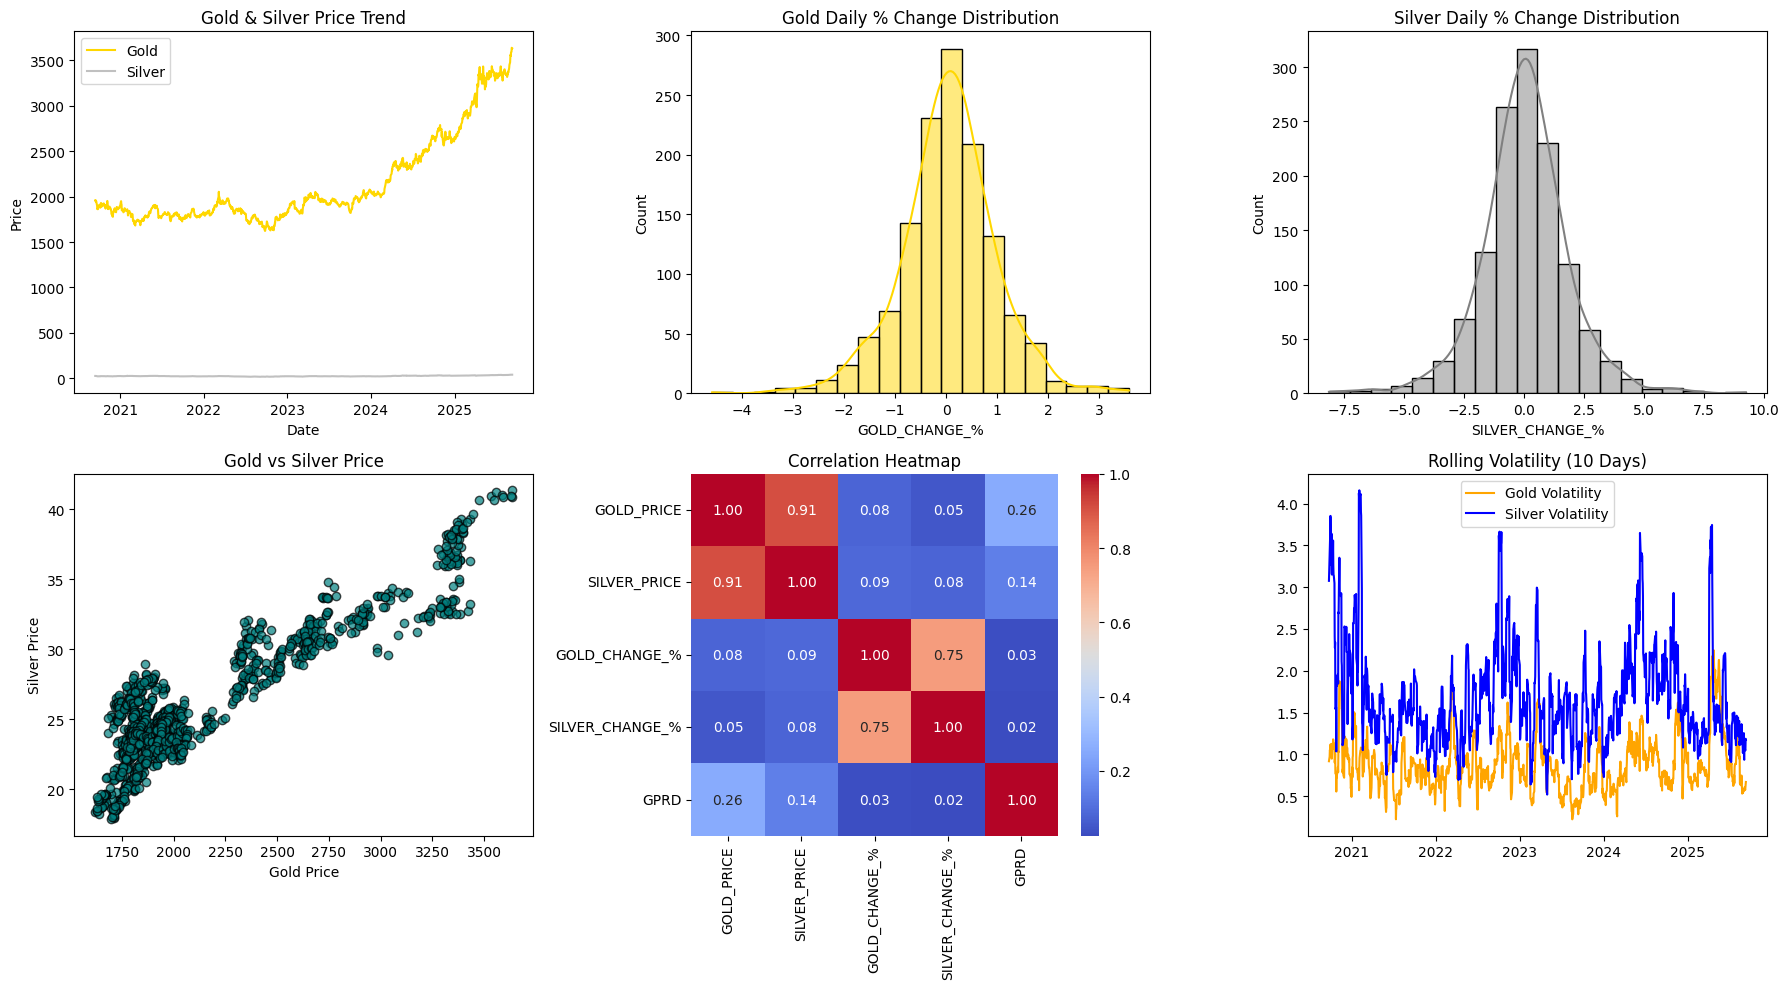

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1. Load Dataset
# -------------------------
file_path = "/content/drive/MyDrive/ML/Gold-Silver-GeopoliticalRisk_HistoricalData.csv"
df = pd.read_csv(file_path)

# Convert DATE column to datetime
df['DATE'] = pd.to_datetime(df['DATE'], dayfirst=True)

# Sort by date
df = df.sort_values('DATE')

# -------------------------
# 2. Create Graphs
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(hspace=0.4, wspace=0.4)

# (a) Gold & Silver Price Trend
axes[0,0].plot(df['DATE'], df['GOLD_PRICE'], label='Gold', color='gold')
axes[0,0].plot(df['DATE'], df['SILVER_PRICE'], label='Silver', color='silver')
axes[0,0].set_title('Gold & Silver Price Trend')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Price')
axes[0,0].legend()

# (b) Gold Daily % Change Distribution
sns.histplot(df['GOLD_CHANGE_%'].dropna(), bins=20, kde=True, color='gold', ax=axes[0,1])
axes[0,1].set_title('Gold Daily % Change Distribution')

# (c) Silver Daily % Change Distribution
sns.histplot(df['SILVER_CHANGE_%'].dropna(), bins=20, kde=True, color='gray', ax=axes[0,2])
axes[0,2].set_title('Silver Daily % Change Distribution')

# (d) Scatter Plot Gold vs Silver Price
axes[1,0].scatter(df['GOLD_PRICE'], df['SILVER_PRICE'], alpha=0.7, color='teal', edgecolor='k')
axes[1,0].set_title('Gold vs Silver Price')
axes[1,0].set_xlabel('Gold Price')
axes[1,0].set_ylabel('Silver Price')

# (e) Correlation Heatmap
corr = df[['GOLD_PRICE','SILVER_PRICE','GOLD_CHANGE_%','SILVER_CHANGE_%','GPRD']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

# (f) Volatility (Rolling Std)
df['Gold_Volatility'] = df['GOLD_CHANGE_%'].rolling(10).std()
df['Silver_Volatility'] = df['SILVER_CHANGE_%'].rolling(10).std()
axes[1,2].plot(df['DATE'], df['Gold_Volatility'], label='Gold Volatility', color='orange')
axes[1,2].plot(df['DATE'], df['Silver_Volatility'], label='Silver Volatility', color='blue')
axes[1,2].set_title('Rolling Volatility (10 Days)')
axes[1,2].legend()

plt.tight_layout()
plt.show()
